# MAKİNE ÖĞRENMESİ - 401

### GEREKLİ KÜTÜPHANELER

In [45]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import scale, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import confusion_matrix, accuracy_score, mean_squared_error, r2_score, roc_auc_score, roc_curve, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [3]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

## 1. LOJİSTİK REGROSTON MODEL VE TAHMİN

## VERİ SETİ HİKAYESİ ve PROBLEM: ŞEKER HASTALIĞI TAHMİNİ

In [4]:
df = pd.read_csv("./diabetes.csv")

In [6]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
df.shape

(768, 9)

In [9]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [14]:
y = df["Outcome"]
X = df.drop(["Outcome"], axis = 1)

In [16]:
y.head()

0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64

In [17]:
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [25]:
loj_model = LogisticRegression(solver="liblinear").fit(X, y)

In [26]:
loj_model.intercept_

array([-5.89066097])

In [27]:
loj_model.coef_

array([[ 1.17042030e-01,  2.83845263e-02, -1.68918562e-02,
         7.55581552e-04, -6.42379703e-04,  5.97597102e-02,
         6.76888410e-01,  7.23931450e-03]])

In [28]:
loj_model.predict(X)[0:10]

array([1, 0, 1, 0, 1, 0, 0, 1, 1, 0])

In [29]:
y[0:10]

0    1
1    0
2    1
3    0
4    1
5    0
6    1
7    0
8    1
9    1
Name: Outcome, dtype: int64

In [30]:
##modelin basarisi
y_pred = loj_model.predict(X)

In [31]:
confusion_matrix(y, y_pred)

array([[448,  52],
       [121, 147]])

In [32]:
accuracy_score(y, y_pred)

0.7747395833333334

In [34]:
classification_report(y, y_pred)

'              precision    recall  f1-score   support\n\n           0       0.79      0.90      0.84       500\n           1       0.74      0.55      0.63       268\n\n    accuracy                           0.77       768\n   macro avg       0.76      0.72      0.73       768\nweighted avg       0.77      0.77      0.77       768\n'

In [35]:
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.90      0.84       500
           1       0.74      0.55      0.63       268

    accuracy                           0.77       768
   macro avg       0.76      0.72      0.73       768
weighted avg       0.77      0.77      0.77       768



In [36]:
loj_model.predict_proba(X)[0:10]

array([[0.35045636, 0.64954364],
       [0.91700024, 0.08299976],
       [0.22480294, 0.77519706],
       [0.92135853, 0.07864147],
       [0.1674049 , 0.8325951 ],
       [0.79895254, 0.20104746],
       [0.88014921, 0.11985079],
       [0.27805284, 0.72194716],
       [0.32055182, 0.67944818],
       [0.92272181, 0.07727819]])

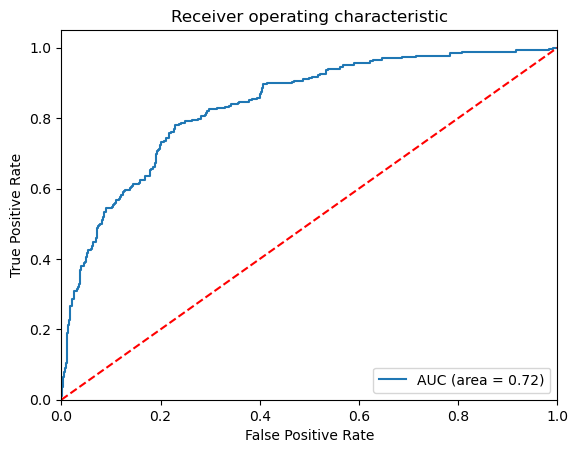

In [37]:
logit_roc_auc = roc_auc_score(y, loj_model.predict(X))
fpr, tpr, thresholds = roc_curve(y, loj_model.predict_proba(X)[:,1])
plt.figure()
plt.plot(fpr, tpr, label='AUC (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.savefig('Log_ROC')
plt.show()

### 1.1 LOJİSTİK REGRESYON MODEL TUNING

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size = 0.30,
                                                    random_state = 42)

In [40]:
loj_model = LogisticRegression(solver="liblinear").fit(X_train, y_train)

In [42]:
y_pred = loj_model.predict(X_test)

In [44]:
print(accuracy_score(y_test, y_pred))

0.7532467532467533


In [48]:
cross_val_score(loj_model,X_test, y_test, cv = 10).mean()

np.float64(0.7704710144927536)

## 2. K EN YAKIN KOMŞU ALGORİTMASI (KNN) MODEL VE TAHMİN

In [49]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [50]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size = 0.30,
                                                    random_state = 42)

In [51]:
knn_model = KNeighborsClassifier().fit(X_train, y_train)

In [52]:
knn_model

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [53]:
y_pred= knn_model.predict(X_test)

In [54]:
accuracy_score(y_test, y_pred)

0.6883116883116883

In [55]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.75      0.76       151
           1       0.55      0.56      0.56        80

    accuracy                           0.69       231
   macro avg       0.66      0.66      0.66       231
weighted avg       0.69      0.69      0.69       231



### 2.1. K EN YAKIN KOMŞU ALGORİTMASI (KNN) MODEL TUNING

In [64]:
knn = KNeighborsClassifier()

In [65]:
np.arange(1,50)

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])

In [66]:
knn_params = {"n_neighbors": np.arange(1,50)}

In [67]:
knn_cv_model = GridSearchCV(knn, knn_params, cv = 10).fit(X_train, y_train)

In [68]:
knn_cv_model.best_score_

np.float64(0.748637316561845)

In [69]:
knn_cv_model.best_params_

{'n_neighbors': np.int64(11)}

In [70]:
##final modeli

In [74]:
knn_tuned = KNeighborsClassifier(n_neighbors=11).fit(X_train, y_train)

In [75]:
y_pred= knn_tuned.predict(X_test)

In [76]:
accuracy_score(y_test, y_pred)

0.7316017316017316

In [78]:
knn_tuned.score(X_test, y_test)

0.7316017316017316

## 3. DESTEK VEKTÖR MAKİNELERİ (SVM) MODEL VE TAHMİN

In [79]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [80]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size = 0.30,
                                                    random_state = 42)

In [81]:
svm_model = SVC().fit(X_train, y_train)

In [82]:
svm_model

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [84]:
svm_model = SVC(kernel = "linear").fit(X_train, y_train)

In [85]:
svm_model

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [91]:
y_pred = svm_model.predict(X_test)

In [92]:
accuracy_score(y_test, y_pred)

0.7445887445887446

### 3.1 DESTEK VEKTÖR MAKİNELERİ (SVM) MODEL TUNING

In [100]:
svm = SVC()

In [101]:
svm_params = {"C": np.arange(1,10), "kernel": ["linear", "rbf"]}

In [103]:
svm_cv_model = GridSearchCV(svm, svm_params, cv=5, n_jobs =-1, verbose =2).fit(X_train, y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


In [104]:
svm_cv_model.best_score_

np.float64(0.7839044652128765)

In [105]:
svm_cv_model.best_params_

{'C': np.int64(2), 'kernel': 'linear'}

In [106]:
##final modeli

In [111]:
svm_tuned = SVC(C=2, kernel = "linear").fit(X_train,y_train)

In [112]:
y_pred = svm_tuned.predict(X_test)

In [113]:
accuracy_score(y_test, y_pred)

0.7445887445887446

## 4. YAPAY SİNİR AĞLARI ALGORİTMASI (ÇOK KATMANLI ALGILAYICILAR) MODEL VE TAHMİN

In [114]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [115]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size = 0.30,
                                                    random_state = 42)

In [116]:
mlpc_model = MLPClassifier().fit(X_train, y_train)

In [117]:
mlpc_model.coefs_

[array([[ 1.97638487e-01,  1.07919026e-01,  8.98678266e-02,
          9.43060672e-02,  6.45318886e-02,  9.70524901e-02,
          1.43994291e-01,  1.64409850e-01,  5.21296787e-02,
          2.64333111e-02, -1.78471459e-01, -1.99809544e-02,
          1.25174308e-01,  1.87050946e-01, -4.93357452e-02,
          8.99156089e-02,  1.69219493e-01, -1.22374152e-02,
          1.01098119e-02,  1.99119793e-01, -1.59773985e-01,
         -2.38660749e-01, -2.13069284e-01, -8.95507364e-02,
         -2.57730675e-01, -8.53802660e-02, -1.10784313e-01,
         -1.29237348e-01,  2.20364011e-01, -4.26328114e-02,
         -8.29252584e-02,  2.33223233e-01, -1.55773572e-04,
         -1.24168513e-01,  2.26263680e-01, -1.56873237e-04,
          2.11322845e-01, -1.51050466e-01, -1.66510825e-01,
         -6.42457450e-02,  9.51228026e-02, -1.72859826e-04,
         -1.19638016e-01, -1.00215200e-01, -6.03276137e-02,
          1.93403773e-01, -1.88648570e-02, -2.56217628e-01,
          4.48568510e-02, -1.48730917e-0

In [118]:
?mlpc_model

Type:        MLPClassifier
String form: MLPClassifier()
File:        c:\users\hkoca\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py
Docstring:  
Multi-layer Perceptron classifier.

This model optimizes the log-loss function using LBFGS or stochastic
gradient descent.

.. versionadded:: 0.18

Parameters
----------
hidden_layer_sizes : array-like of shape(n_layers - 2,), default=(100,)
    The ith element represents the number of neurons in the ith
    hidden layer.

activation : {'identity', 'logistic', 'tanh', 'relu'}, default='relu'
    Activation function for the hidden layer.

    - 'identity', no-op activation, useful to implement linear bottleneck,
      returns f(x) = x

    - 'logistic', the logistic sigmoid function,
      returns f(x) = 1 / (1 + exp(-x)).

    - 'tanh', the hyperbolic tan function,
      returns f(x) = tanh(x).

    - 'relu', the rectified linear unit function,
      returns f(x) = max(0, x)

solver : {'lbfgs', 'sgd', 'adam'}, defa

In [119]:
y_pred = mlpc_model.predict(X_test)

In [121]:
accuracy_score(y_test, y_pred)

0.6796536796536796

### 4.1. YAPAY SİNİR AĞLARI ALGORİTMASI (ÇOK KATMANLI ALGILAYICILAR) MODEL TUNING

In [124]:
mlpc_params = {"alpha": [1, 5, 0.1, 0.01, 0.03, 0.0005, 0.0001],
               "hidden_layer_sizes": [(10,10), (100, 100, 100), (100, 100), (3,5)]}

In [125]:
mlpc = MLPClassifier(solver = "lbfgs")

In [127]:
mlpc_cv_model = GridSearchCV(mlpc, mlpc_params, cv =10, n_jobs = -1, verbose =2).fit(X_train, y_train)

Fitting 10 folds for each of 28 candidates, totalling 280 fits


C:\Users\hkoca\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


In [128]:
mlpc_cv_model

,estimator,MLPClassifier(solver='lbfgs')
,param_grid,"{'alpha': [1, 5, ...], 'hidden_layer_sizes': [(10, ...), (100, ...), ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,10
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,hidden_layer_sizes,"(10, ...)"


In [130]:
mlpc_cv_model.best_params_

{'alpha': 5, 'hidden_layer_sizes': (10, 10)}

In [133]:
##final modeli

In [136]:
mlpc_tuned = MLPClassifier(solver = "lbfgs",alpha = 5,hidden_layer_sizes = (10,10)).fit(X_train,y_train)

C:\Users\hkoca\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


In [137]:
y_pred = mlpc_tuned.predict(X_test)

In [138]:
accuracy_score(y_test, y_pred)

0.7229437229437229

In [ ]:
##activasyonu loj denemeli yapalım.

In [139]:
mlpc_params1 = {"alpha": [1, 5, 0.1, 0.01, 0.03, 0.0005, 0.0001],
               "hidden_layer_sizes": [(10,10), (100, 100, 100), (100, 100), (3,5)]}

In [141]:
mlpc1 = MLPClassifier(solver = "lbfgs", activation = "logistic")

In [143]:
mlpc_cv_model1 = GridSearchCV(mlpc1, mlpc_params1, cv =10, n_jobs = -1, verbose =2).fit(X_train, y_train)

Fitting 10 folds for each of 28 candidates, totalling 280 fits


C:\Users\hkoca\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


In [145]:
mlpc_cv_model1

,estimator,MLPClassifier...olver='lbfgs')
,param_grid,"{'alpha': [1, 5, ...], 'hidden_layer_sizes': [(10, ...), (100, ...), ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,10
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,hidden_layer_sizes,"(100, ...)"


In [144]:
mlpc_cv_model1.best_params_

{'alpha': 5, 'hidden_layer_sizes': (100, 100)}

In [146]:
##final modeli 2 

In [147]:
mlpc_tuned1 = MLPClassifier(solver = "lbfgs",alpha = 5, activation='logistic', hidden_layer_sizes = (100,100)).fit(X_train,y_train)

C:\Users\hkoca\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


In [149]:
y_pred1 = mlpc_tuned1.predict(X_test)

In [150]:
accuracy_score(y_test, y_pred1)

0.7229437229437229

In [153]:
##Standartlaştırma

In [154]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [155]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size = 0.30,
                                                    random_state = 42)

In [156]:
scaler = StandardScaler()

In [157]:
scaler.fit(X_train)
X_train = scaler.transform(X_train)

In [158]:
scaler.fit(X_test)
X_test = scaler.transform(X_test)

In [159]:
mlpc_params1 = {"alpha": [1, 5, 0.1, 0.01, 0.03, 0.0005, 0.0001],
               "hidden_layer_sizes": [(10,10), (100, 100, 100), (100, 100), (3,5)]}

In [160]:
mlpc1 = MLPClassifier(solver = "lbfgs", activation = "logistic")

In [161]:
mlpc_cv_model1 = GridSearchCV(mlpc1, mlpc_params1, cv =10, n_jobs = -1, verbose =2).fit(X_train, y_train)

Fitting 10 folds for each of 28 candidates, totalling 280 fits


In [162]:
mlpc_cv_model1

,estimator,MLPClassifier...olver='lbfgs')
,param_grid,"{'alpha': [1, 5, ...], 'hidden_layer_sizes': [(10, ...), (100, ...), ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,10
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,hidden_layer_sizes,"(3, ...)"


In [164]:
mlpc_cv_model1.best_params_

{'alpha': 1, 'hidden_layer_sizes': (3, 5)}

In [165]:
mlpc_tuned1 = MLPClassifier(solver = "lbfgs",alpha = 1, activation='logistic', hidden_layer_sizes = (3,5)).fit(X_train,y_train)

In [166]:
y_pred1 = mlpc_tuned1.predict(X_test)

In [167]:
accuracy_score(y_test, y_pred1)

0.7575757575757576

## 5. CART (CLASSIFICATION AND REGRESSION TREE) MODEL VE TAHMİN

In [168]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [169]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size = 0.30,
                                                    random_state = 42)

In [170]:
cart_model = DecisionTreeClassifier().fit(X_train, y_train)

In [171]:
cart_model

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [172]:
y_pred = cart_model.predict(X_test)

In [173]:
accuracy_score(y_test, y_pred)

0.6883116883116883

### 5.1 CART (CLASSIFICATION AND REGRESSION TREE) MODEL TUNING

In [175]:
cart = DecisionTreeClassifier()

In [180]:
cart_params = {"max_depth": [1,3,5,8,10],
               "min_samples_split": [2,3,5,10,20,50]}

In [181]:
cart_cv_model = GridSearchCV(cart, cart_params, cv =10, n_jobs=-1, verbose = 2).fit(X_train, y_train)

Fitting 10 folds for each of 30 candidates, totalling 300 fits


In [182]:
cart_cv_model.best_params_

{'max_depth': 5, 'min_samples_split': 20}

In [183]:
##final model

In [184]:
cart_tuned = DecisionTreeClassifier(max_depth =5, min_samples_split = 20).fit(X_train, y_train)

In [186]:
y_pred = cart_tuned.predict(X_test)

In [187]:
accuracy_score(y_test, y_pred)

0.7532467532467533

## 6. RANDOM FORESTS MODEL VE TAHMİN

In [190]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [191]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size = 0.30,
                                                    random_state = 42)

In [192]:
rf_model = RandomForestClassifier().fit(X_train, y_train)

In [193]:
rf_model

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [195]:
y_pred = rf_model.predict(X_test)

In [196]:
accuracy_score(y_test, y_pred)

0.7532467532467533

### 6.1. RANDOM FORESTS MODEL TUNING

In [197]:
rf = RandomForestClassifier()

In [198]:
rf_params = {"n_estimators": [100,200,500,1000],
             "max_features": [3,5,7,8],
             "min_samples_split": [2,5,10,20]}

In [199]:
rf_cv_model = GridSearchCV(rf, rf_params, cv= 10, n_jobs =-1, verbose =2).fit(X_train, y_train)

Fitting 10 folds for each of 64 candidates, totalling 640 fits


In [200]:
rf_cv_model.best_params_

{'max_features': 7, 'min_samples_split': 10, 'n_estimators': 200}

In [201]:
#final modeli

In [202]:
rf_tuned= RandomForestClassifier(max_features =7,
                                min_samples_split = 10,
                                n_estimators =200).fit(X_train,y_train)

In [203]:
y_pred= rf_tuned.predict(X_test)

In [204]:
accuracy_score(y_test, y_pred)

0.7532467532467533

#### degisken onem düzeyi

In [210]:
rf_tuned

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,10
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,7
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [211]:
rf_tuned.feature_importances_

array([0.04013065, 0.39697655, 0.06550048, 0.03953069, 0.04771866,
       0.16855369, 0.09687982, 0.14470946])

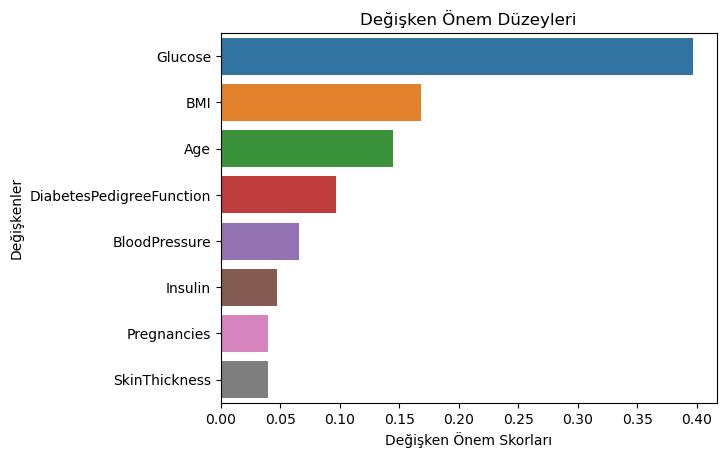

In [212]:
feature_imp = pd.Series(rf_tuned.feature_importances_,
                        index = X_train.columns).sort_values(ascending=False)

sns.barplot(x=feature_imp, y=feature_imp.index, hue=feature_imp.index)
plt.xlabel('Değişken Önem Skorları')
plt.ylabel('Değişkenler')
plt.title("Değişken Önem Düzeyleri")
plt.show()

## 7. GRADIENT BOOSTING MACHINES (GBM) MODEL VE TAHMİN

In [220]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [221]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size = 0.30,
                                                    random_state = 42)

In [224]:
gbm_model = GradientBoostingClassifier().fit(X_train, y_train)

In [225]:
gbm_model

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [226]:
?gbm_model

Type:        GradientBoostingClassifier
String form: GradientBoostingClassifier()
Length:      100
File:        c:\users\hkoca\anaconda3\lib\site-packages\sklearn\ensemble\_gb.py
Docstring:  
Gradient Boosting for classification.

This algorithm builds an additive model in a forward stage-wise fashion; it
allows for the optimization of arbitrary differentiable loss functions. In
each stage ``n_classes_`` regression trees are fit on the negative gradient
of the loss function, e.g. binary or multiclass log loss. Binary
classification is a special case where only a single regression tree is
induced.

:class:`~sklearn.ensemble.HistGradientBoostingClassifier` is a much faster variant
of this algorithm for intermediate and large datasets (`n_samples >= 10_000`) and
supports monotonic constraints.

Read more in the :ref:`User Guide <gradient_boosting>`.

Parameters
----------
loss : {'log_loss', 'exponential'}, default='log_loss'
    The loss function to be optimized. 'log_loss' refers to bin

In [227]:
y_pred = gbm_model.predict(X_test)

In [228]:
accuracy_score(y_test, y_pred)

0.7489177489177489

## 7.1. GRADIENT BOOSTING MACHINES (GBM) MODEL TUNING

In [229]:
gbm = GradientBoostingClassifier()

In [230]:
gbm_params = {"learning_rate": [0.1, 0.01, 0.001, 0.05],
              "n_estimators": [100, 300, 500, 1000],
              "max_depth": [2,3,5,8]}

In [231]:
gbm_cv_model = GridSearchCV(gbm, gbm_params, cv=10, n_jobs=-1, verbose =2).fit(X_train,y_train)

Fitting 10 folds for each of 64 candidates, totalling 640 fits


In [232]:
gbm_cv_model.best_params_

{'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 300}

In [233]:
#final modeli

In [235]:
gbm_tuned = GradientBoostingClassifier(learning_rate =0.01,
                                       max_depth = 5,
                                       n_estimators =300).fit(X_train, y_train)

In [237]:
y_pred = gbm_tuned.predict(X_test)
accuracy_score(y_test, y_pred)

0.7489177489177489

#### degisken onem duzeyleri

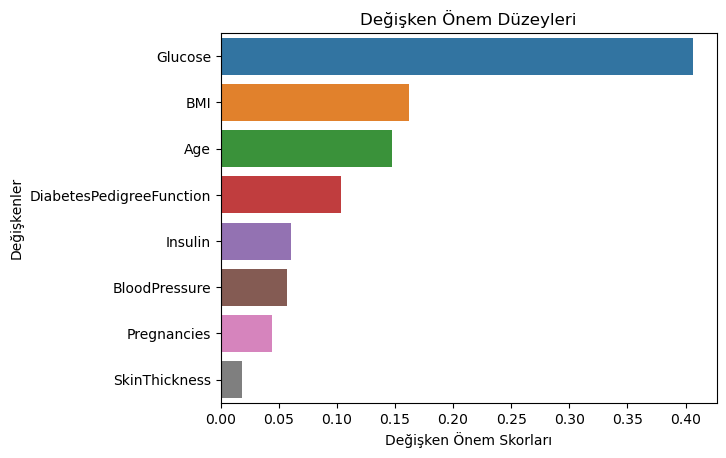

In [238]:
feature_imp = pd.Series(gbm_tuned.feature_importances_,
                        index = X_train.columns).sort_values(ascending=False)

sns.barplot(x=feature_imp, y=feature_imp.index, hue=feature_imp.index)
plt.xlabel('Değişken Önem Skorları')
plt.ylabel('Değişkenler')
plt.title("Değişken Önem Düzeyleri")
plt.show()

## 8. XGBOOST MODEL VE TAHMİN

In [239]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [240]:
!pip install xgboost

In [241]:
from xgboost import XGBClassifier

In [242]:
xgb_model = XGBClassifier().fit(X_train, y_train)

In [243]:
xgb_model

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [244]:
?xgb_model

Type:        XGBClassifier
String form:
XGBClassifier(base_score=None, booster=None, callbacks=None,
           colsample_bylevel=None <...> , multi_strategy=None, n_estimators=None,
           n_jobs=None, num_parallel_tree=None, ...)
File:        c:\users\hkoca\anaconda3\lib\site-packages\xgboost\sklearn.py
Docstring:  
Implementation of the scikit-learn API for XGBoost classification.
See :doc:`/python/sklearn_estimator` for more information.

Parameters
----------

    n_estimators : Optional[int]
        Number of boosting rounds.

    max_depth :  typing.Optional[int]

        Maximum tree depth for base learners.

    max_leaves : typing.Optional[int]

        Maximum number of leaves; 0 indicates no limit.

    max_bin : typing.Optional[int]

        If using histogram-based algorithm, maximum number of bins per feature

    grow_policy : typing.Optional[str]

        Tree growing policy.

        - depthwise: Favors splitting at nodes closest to the node,
        - lossguide: 

In [245]:
y_pred = xgb_model.predict(X_test)

In [246]:
accuracy_score(y_test, y_pred)

0.7359307359307359

## 8.1. XGBOOST MODEL TUNING

In [247]:
xgb = XGBClassifier()

In [248]:
xgb_params = {"n_estimators": [100,500,1000],
              "subsample": [0.6, 0.8, 1],
              "max_depth": [3,5,7],
              "learning_rate": [0.1,0.01,0.001]}

In [249]:
xgb_cv_model = GridSearchCV(xgb, xgb_params, cv =10, n_jobs=-1, verbose =2).fit(X_train, y_train)

Fitting 10 folds for each of 81 candidates, totalling 810 fits


In [250]:
xgb_cv_model.best_params_

{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 500, 'subsample': 1}

In [251]:
#final modeli

In [252]:
xgb_tuned = XGBClassifier(learning_rate= 0.01, 
                                max_depth= 3, 
                                n_estimators= 500, 
                                subsample= 1).fit(X_train, y_train)

In [253]:
y_pred = xgb_tuned.predict(X_test)

In [254]:
accuracy_score(y_test, y_pred)

0.7619047619047619

#### degisken onem duzeyı

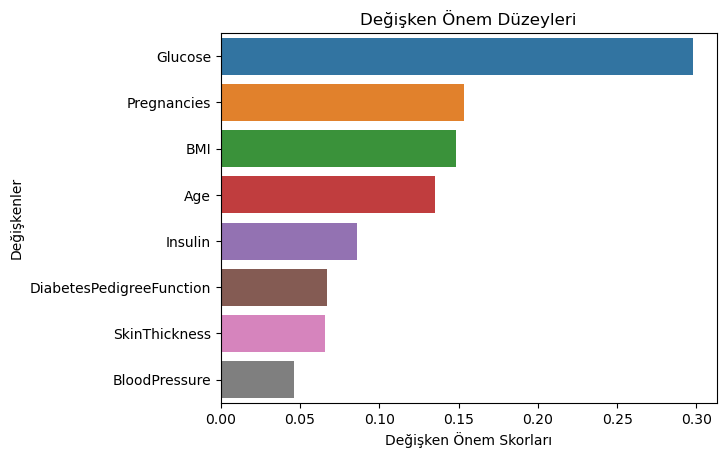

In [255]:
feature_imp = pd.Series(xgb_tuned.feature_importances_,
                        index = X_train.columns).sort_values(ascending=False)

sns.barplot(x=feature_imp, y=feature_imp.index, hue=feature_imp.index)
plt.xlabel('Değişken Önem Skorları')
plt.ylabel('Değişkenler')
plt.title("Değişken Önem Düzeyleri")
plt.show()

## 9. LIGHTGBM MODEL VE TAHMİN

In [256]:
!pip install lightgbm

In [257]:
from lightgbm import LGBMClassifier

In [259]:
lgbm_model = LGBMClassifier().fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 188, number of negative: 349
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000348 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 606
[LightGBM] [Info] Number of data points in the train set: 537, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.350093 -> initscore=-0.618630
[LightGBM] [Info] Start training from score -0.618630
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

In [260]:
lgbm_model

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [261]:
?lgbm_model

Type:           LGBMClassifier
String form:    LGBMClassifier()
File:           c:\users\hkoca\anaconda3\lib\site-packages\lightgbm\sklearn.py
Docstring:      LightGBM classifier.
Init docstring:
Construct a gradient boosting model.

Parameters
----------
boosting_type : str, optional (default='gbdt')
    'gbdt', traditional Gradient Boosting Decision Tree.
    'dart', Dropouts meet Multiple Additive Regression Trees.
    'rf', Random Forest.
num_leaves : int, optional (default=31)
    Maximum tree leaves for base learners.
max_depth : int, optional (default=-1)
    Maximum tree depth for base learners, <=0 means no limit.
    If setting this to a positive value, consider also changing ``num_leaves`` to ``<= 2^max_depth``.
learning_rate : float, optional (default=0.1)
    Boosting learning rate.
    You can use ``callbacks`` parameter of ``fit`` method to shrink/adapt learning rate
    in training using ``reset_parameter`` callback.
    Note, that this will ignore the ``learning_rate``

In [262]:
y_pred = lgbm_model.predict(X_test)

In [263]:
accuracy_score(y_test, y_pred)

0.7229437229437229

### 9.1. LIGHTGBM MODEL TUNING

In [264]:
lgbm = LGBMClassifier()

In [265]:
lgbm_params = {"learning_rate": [0.001, 0.01, 0.1],
               "n_estimators": [200,500,1000],
               "max_depth": [1,2,3,5,8]}

In [266]:
lgbm_cv_mdoel = GridSearchCV(lgbm,lgbm_params, cv=10, n_jobs=-1,verbose=2).fit(X_train,y_train)

Fitting 10 folds for each of 45 candidates, totalling 450 fits
[LightGBM] [Info] Number of positive: 188, number of negative: 349
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000414 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 606
[LightGBM] [Info] Number of data points in the train set: 537, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.350093 -> initscore=-0.618630
[LightGBM] [Info] Start training from score -0.618630
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

In [267]:
lgbm_cv_mdoel.best_params_

{'learning_rate': 0.01, 'max_depth': 1, 'n_estimators': 500}

In [ ]:
#final modeli

In [268]:
lgbm_tuned = LGBMClassifier(learning_rate= 0.01, 
                            max_depth= 1, 
                            n_estimators= 500).fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 188, number of negative: 349
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000278 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 606
[LightGBM] [Info] Number of data points in the train set: 537, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.350093 -> initscore=-0.618630
[LightGBM] [Info] Start training from score -0.618630
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

In [269]:
y_pred = lgbm_tuned.predict(X_test)

In [270]:
accuracy_score(y_test, y_pred)

0.7575757575757576

#### degiskenlerin onem duzeyi

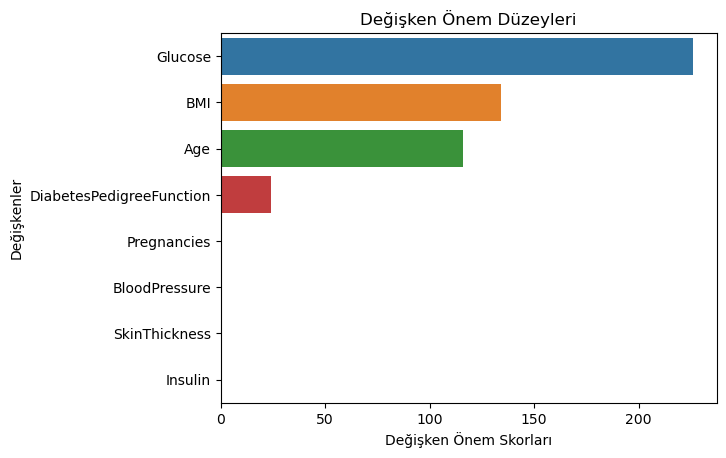

In [271]:
feature_imp = pd.Series(lgbm_tuned.feature_importances_,
                        index = X_train.columns).sort_values(ascending=False)

sns.barplot(x=feature_imp, y=feature_imp.index, hue=feature_imp.index)
plt.xlabel('Değişken Önem Skorları')
plt.ylabel('Değişkenler')
plt.title("Değişken Önem Düzeyleri")
plt.show()

## 10. CATBOOST MODEL VE TAHMİN

In [272]:
!pip install catboost

In [273]:
from catboost import CatBoostClassifier

In [275]:
catb_model = CatBoostClassifier().fit(X_train, y_train, verbose=False)

In [276]:
y_pred = catb_model.predict(X_test)

In [277]:
accuracy_score(y_test, y_pred)

0.7402597402597403

### 10.1. CATBOOST MODEL TUNING

In [281]:
catb = CatBoostClassifier()

In [284]:
catb_params = {"iterations": [200,500,1000],
              "learning_rate": [0.01,0.03,0.1],
              "depth": [4,5,8]}

In [285]:
catb_cv_model = GridSearchCV(catb, catb_params, cv=5, n_jobs=-1, verbose =2).fit(X_train,y_train)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
0:	learn: 0.6863312	total: 7.63ms	remaining: 1.52s
1:	learn: 0.6811157	total: 14.6ms	remaining: 1.45s
2:	learn: 0.6752970	total: 22.3ms	remaining: 1.46s
3:	learn: 0.6697432	total: 31.6ms	remaining: 1.55s
4:	learn: 0.6641758	total: 39ms	remaining: 1.52s
5:	learn: 0.6576656	total: 46.5ms	remaining: 1.5s
6:	learn: 0.6521870	total: 54.3ms	remaining: 1.5s
7:	learn: 0.6465564	total: 61ms	remaining: 1.46s
8:	learn: 0.6407595	total: 70ms	remaining: 1.49s
9:	learn: 0.6357725	total: 74.8ms	remaining: 1.42s
10:	learn: 0.6299942	total: 82.3ms	remaining: 1.41s
11:	learn: 0.6240480	total: 87.2ms	remaining: 1.37s
12:	learn: 0.6196095	total: 92.1ms	remaining: 1.32s
13:	learn: 0.6148715	total: 101ms	remaining: 1.35s
14:	learn: 0.6092626	total: 110ms	remaining: 1.35s
15:	learn: 0.6046764	total: 119ms	remaining: 1.37s
16:	learn: 0.6012725	total: 127ms	remaining: 1.37s
17:	learn: 0.5958121	total: 136ms	remaining: 1.37s
18:	learn: 0.5903243	tota

In [286]:
catb_cv_model.best_params_

{'depth': 8, 'iterations': 200, 'learning_rate': 0.01}

In [287]:
#final modeli

In [288]:
catb_tuned = CatBoostClassifier(depth= 8, 
                                iterations= 200, 
                                learning_rate= 0.01).fit(X_train, y_train)

0:	learn: 0.6863312	total: 4.64ms	remaining: 924ms
1:	learn: 0.6811157	total: 10.8ms	remaining: 1.07s
2:	learn: 0.6752970	total: 15.1ms	remaining: 992ms
3:	learn: 0.6697432	total: 20ms	remaining: 980ms
4:	learn: 0.6641758	total: 23.8ms	remaining: 928ms
5:	learn: 0.6576656	total: 28ms	remaining: 906ms
6:	learn: 0.6521870	total: 32ms	remaining: 882ms
7:	learn: 0.6465564	total: 35.9ms	remaining: 861ms
8:	learn: 0.6407595	total: 39.8ms	remaining: 845ms
9:	learn: 0.6357725	total: 43.7ms	remaining: 830ms
10:	learn: 0.6299942	total: 47.4ms	remaining: 815ms
11:	learn: 0.6240480	total: 51.3ms	remaining: 804ms
12:	learn: 0.6196095	total: 55.1ms	remaining: 792ms
13:	learn: 0.6148715	total: 58.6ms	remaining: 778ms
14:	learn: 0.6092626	total: 62.1ms	remaining: 766ms
15:	learn: 0.6046764	total: 65.6ms	remaining: 754ms
16:	learn: 0.6012725	total: 69.1ms	remaining: 744ms
17:	learn: 0.5958121	total: 72.1ms	remaining: 729ms
18:	learn: 0.5903243	total: 74.9ms	remaining: 713ms
19:	learn: 0.5866024	total: 

In [291]:
y_pred = catb_tuned.predict(X_test)

In [292]:
accuracy_score(y_test, y_pred)

0.7532467532467533

#### degısken onem duzeyı

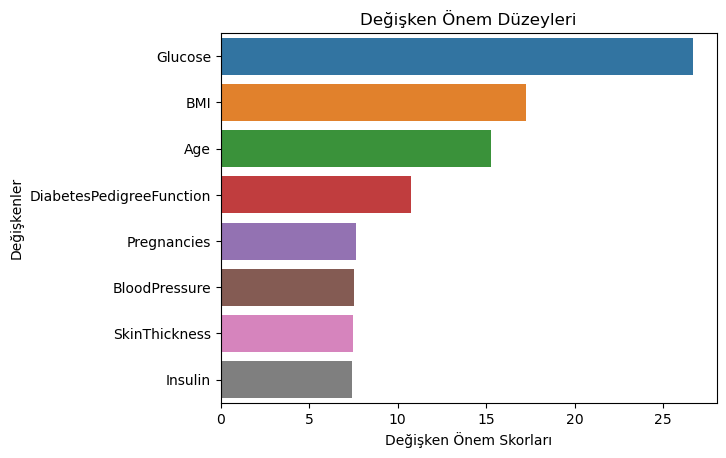

In [293]:
feature_imp = pd.Series(catb_tuned.feature_importances_,
                        index = X_train.columns).sort_values(ascending=False)

sns.barplot(x=feature_imp, y=feature_imp.index, hue=feature_imp.index)
plt.xlabel('Değişken Önem Skorları')
plt.ylabel('Değişkenler')
plt.title("Değişken Önem Düzeyleri")
plt.show()

## TÜM MODELLERİN KARŞILAŞTIRILMASI

In [304]:
modeller = [
    knn_tuned,
    loj_model,
    svm_tuned,
    mlpc_tuned,
    cart_tuned,
    rf_tuned,
    gbm_tuned,
    catb_tuned,
    lgbm_tuned,
    xgb_tuned
]

# Boş bir liste oluşturup sonuçları burada toplayalım (en hızlı ve sorunsuz yöntem)
veri_listesi = []

for model in modeller:
    isimler = model.__class__.__name__
    y_pred = model.predict(X_test)
    dogruluk = accuracy_score(y_test, y_pred)
    veri_listesi.append({"Modeller": isimler, "Accuracy": dogruluk * 100})

# Listeyi tek seferde DataFrame'e dönüştürelim
sonuclar = pd.DataFrame(veri_listesi)


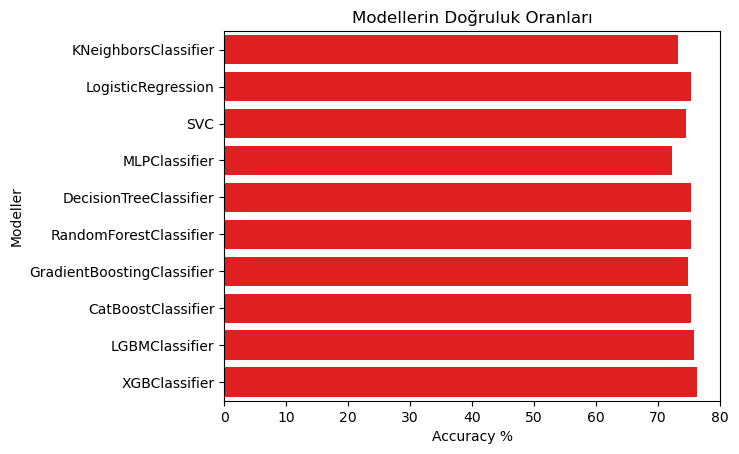

In [305]:
sns.barplot(x='Accuracy', y='Modeller', data=sonuclar, color="r")
plt.xlabel('Accuracy %')
plt.title('Modellerin Doğruluk Oranları');


In [309]:
sonuclar

,Modeller,Accuracy
0,KNeighborsClassifier,73.160173
1,LogisticRegression,75.324675
2,SVC,74.458874
3,MLPClassifier,72.294372
4,DecisionTreeClassifier,75.324675
5,RandomForestClassifier,75.324675
6,GradientBoostingClassifier,74.891775
7,CatBoostClassifier,75.324675
8,LGBMClassifier,75.757576
9,XGBClassifier,76.190476


#### DAHA BAŞKA NE YAPILABİLİR?

1. Değişken Türetme  / Değişken mühendisliği (ÖRNEĞİN; boy ve kilo var biz BMI'ı-vücut kitle endeksi- türettik)
2. Değişken seçme
3. Otomatik ML
4. Model deployment konusunda ek araştırma yapmalıyız..